In [55]:
import torch
import soundfile as sf
from audiomentations import LowPassFilter, HighPassFilter, PitchShift, Gain, BandStopFilter, AddBackgroundNoise, LoudnessNormalization, ApplyImpulseResponse, SevenBandParametricEQ 
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import warnings
import torchaudio
import numpy as np 
from all_data_augmentation_functions import low_pass_filter, high_pass_filter, add_bandstop_filter
from all_data_augmentation_functions import add_gain, apply_seven_band_peq
from all_data_augmentation_functions import display_audio, display_original
from all_data_augmentation_functions import plot_waveform, plot_spectrogram, plot_all
from all_data_augmentation_functions import pitch_shift
import pandas as pd
import random

import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\sharo\Tech Elective\audioDetection\data-augmentation


#### Data Exploration
Before applying data augmentation, it would be beneficial to understand our data a bit better. This means that, for example, when applying our frequency filters, we should not block out any of the main frequency range.


In [56]:
def get_frequency_properties(np_audio, sf):
    # np_audio is numpy array of audio
    # sf is same as sample rate in this context
    spec = np.abs(np.fft.rfft(np_audio))
    freq = np.fft.rfftfreq(len(np_audio), d=1 / sf)
    spec = np.abs(spec)
    amp = spec / spec.sum()
    mean = (freq * amp).sum()
    amp_cumsum = np.cumsum(amp)
    Q25 = freq[len(amp_cumsum[amp_cumsum <= 0.25]) + 1]
    Q75 = freq[len(amp_cumsum[amp_cumsum <= 0.75]) + 1]

    result_d = {
        'mean': float(mean),
        'Q25': float(Q25),
        'Q75': float(Q75),
    }
    return result_d

def audio_to_numpy(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32") 
    return audio_np, sr

In [57]:
audio_np, sr = audio_to_numpy(PATH='../audio_files/original-files/AH_667J_605FB4D5-E0DB-4B9B-8F58-784561C51693.wav')
print(get_frequency_properties(audio_np, sr))

{'mean': 1016.5282312072718, 'Q25': 727.6827663972937, 'Q75': 1275.7000563803795}


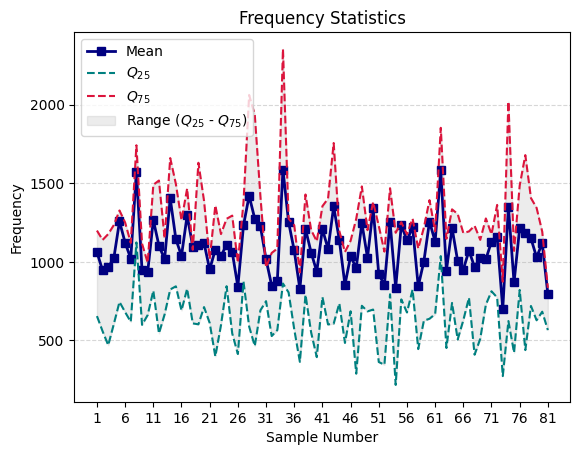

In [58]:
all_frequency_data = {
    'mean': [],
    'Q25': [],
    'Q75': [],
}

count = 0
audio_csv = pd.read_csv('../audio-details/audio_files.csv')
for idx, row in audio_csv.iterrows():
    audio_ID = row["Sample ID"]
    audio_np, sr = audio_to_numpy(PATH=f'../audio_files/original-files/{audio_ID}.wav')
    details = get_frequency_properties(audio_np, sr)
    all_frequency_data['mean'].append(details['mean'])
    all_frequency_data['Q25'].append(details['Q25'])
    all_frequency_data['Q75'].append(details['Q75'])

indices = range(1, len(all_frequency_data['mean'])+1)

plt.plot(indices, all_frequency_data['mean'], label='Mean', marker='s', color='navy', linewidth=2)
plt.plot(indices, all_frequency_data['Q25'], label='$Q_{25}$', linestyle='--', color='teal')
plt.plot(indices, all_frequency_data['Q75'], label='$Q_{75}$', linestyle='--', color='crimson')
plt.fill_between(indices, all_frequency_data['Q25'], all_frequency_data['Q75'], color='gray', alpha=0.15, label='Range ($Q_{25}$ - $Q_{75}$)')

plt.xlabel('Sample Number')
plt.ylabel('Frequency')
plt.title('Frequency Statistics')
plt.xticks(indices[::5])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


In [59]:
def hertz_to_semitones(hertz_val, ref_hz=100):
    semitones = 12 * np.log2(hertz_val / ref_hz)
    return semitones

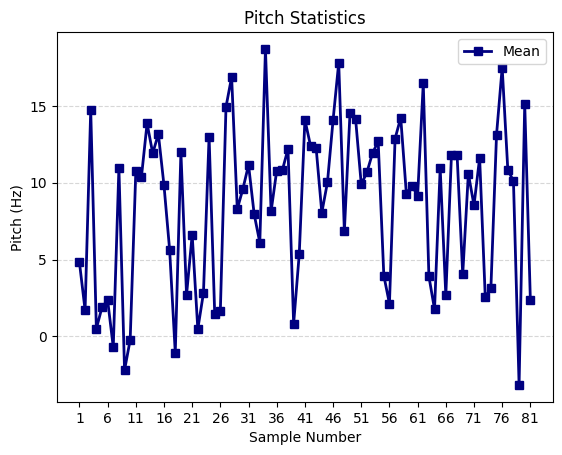

In [60]:
audio_features_csv = pd.read_csv('../audio-details/audio_features.csv')

all_mean_pitches = []

for idx, row in audio_features_csv.iterrows():
    mean_pitch_hertz = row['mean_pitch']
    mean_pitch_semitones = hertz_to_semitones(mean_pitch_hertz)
    all_mean_pitches.append(mean_pitch_semitones)


indices = range(1, len(all_mean_pitches)+1)

plt.plot(indices, all_mean_pitches, label='Mean', marker='s', color='navy', linewidth=2)

plt.xlabel('Sample Number')
plt.ylabel('Pitch (Hz)')
plt.title('Pitch Statistics')
plt.xticks(indices[::5])  # This ensures every index (0, 1, 2...) is marked on the axis
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


#### Constants

In [76]:
LOW_PASS_MIN = 1600
LOW_PASS_MAX = 1800

HIGH_PASS_MIN = 400
HIGH_PASS_MAX = 500

BANDSTOP_MIN_CENTRE = 50
BANDSTOP_MAX_CENTRE = 100
BANDSTOP_MIN_FRACTION = 0.2
BANDSTOP_MAX_FRACTION = 0.5

PITCH_SHIFT_MIN = -2
PITCH_SHIFT_MAX = 2

MAX_GAIN = 5
MIN_GAIN = 5

SEVEN_BAND_MIN = -5
SEVEN_BAND_MAX = 5

#### Implementing Sequential Data Augmentation
The order in which audio data augmentations are applied will affect how the audio sounds. We can explore this by first trying to apply two augmentations sequentially: pitch shift and a frequency filter. 

In [68]:
def get_random_ints():
    x = random.randint(1, 6)
    y = random.randint(1, 6)
    while (x == y): y=random.randint(1, 6)
    return x, y

In [77]:
def do_augmentation(path, do_display_audio, x, y):
    if (do_display_audio): display_original(text="Original audio", PATH=path)
    first_audio=True,
    prev_taudio=None,
    prev_sr=None,
    first_audio = True
    curr_num = x
    for i in range(2):
        if (curr_num == 1):
            new_audio, sr = low_pass_filter(first_audio=first_audio,
                                            PATH=path, 
                                            prob=1,
                                            prev_taudio=prev_taudio, 
                                            prev_sr=prev_sr,
                                            min_freq=LOW_PASS_MIN,
                                            max_freq=LOW_PASS_MAX)
            if (do_display_audio): display_audio(text="After low pass filter", audio=new_audio, sr=sr)
            first_audio = False
            path = None
            prev_taudio = new_audio
            prev_sr = sr
        elif (curr_num == 2):
            new_audio, sr = high_pass_filter(first_audio=first_audio, 
                                            PATH=path,
                                            prob=1,
                                            prev_taudio=prev_taudio,
                                            prev_sr=prev_sr,
                                            min_freq=HIGH_PASS_MIN,
                                            max_freq=HIGH_PASS_MAX)
            if (do_display_audio): display_audio(text="After high pass filter", audio=new_audio, sr=sr)
            first_audio = False
            path = None
            prev_taudio = new_audio
            prev_sr = sr
        elif (curr_num == 3):
            new_audio, sr = add_bandstop_filter(first_audio=first_audio,
                                                PATH=path,
                                                prob=1,
                                                prev_taudio=prev_taudio, 
                                                prev_sr=prev_sr,
                                                min_freq=BANDSTOP_MIN_CENTRE,
                                                max_freq=BANDSTOP_MAX_CENTRE,
                                                min_bf=BANDSTOP_MIN_FRACTION,
                                                max_bf=BANDSTOP_MAX_FRACTION)
            if (do_display_audio): display_audio(text="After applying bandstop filter", audio=new_audio, sr=sr)
            first_audio = False
            path = None
            prev_taudio = new_audio
            prev_sr = sr
        elif (curr_num == 4):
            new_audio, sr = pitch_shift(first_audio=first_audio,
                                        PATH=path,
                                        prob=1,
                                        prev_taudio=prev_taudio, 
                                        prev_sr=prev_sr,
                                        min_semitones=PITCH_SHIFT_MIN,
                                        max_semitones=PITCH_SHIFT_MAX)
            
            if (do_display_audio): display_audio(text="After pitch_shift", audio=new_audio, sr=sr)
            first_audio = False
            path = None
            prev_taudio = new_audio
            prev_sr = sr
        elif (curr_num == 5):
            new_audio, sr = add_gain(first_audio=first_audio, 
                                    PATH=path, 
                                    prob=1,
                                    prev_taudio=prev_taudio, 
                                    prev_sr=prev_sr,
                                    min_gain=MIN_GAIN,
                                    max_gain = MAX_GAIN)
            if (do_display_audio): display_audio(text="After adding gain", audio=new_audio, sr=sr)
            first_audio = False
            path = None
            prev_taudio = new_audio
            prev_sr = sr
        else:
            new_audio, sr = apply_seven_band_peq(first_audio=first_audio,
                                                PATH=path,
                                                prob=1,
                                                prev_taudio=prev_taudio, 
                                                prev_sr=prev_sr,
                                                min_gain=SEVEN_BAND_MIN,
                                                max_gain=SEVEN_BAND_MAX)
            if (do_display_audio): display_audio(text="After applying seven band peq", audio=new_audio, sr=sr)
            first_audio = False
            path = None
            prev_taudio = new_audio
            prev_sr = sr

        curr_num = y
    
    if prev_taudio.ndim == 1:
        # Case that audio is mono
        prev_taudio = prev_taudio.unsqueeze(0) # (1, samples) i.e. (channels, samples)
    else:
        # Case that audio is stereo or multi-channel
        prev_taudio = prev_taudio.T # (channels, samples)

    return prev_taudio, prev_sr


# First, tested this function on just one of the audios 
testing_audio, testing_sr = do_augmentation(path ='../audio_files/original-files/AH_667J_605FB4D5-E0DB-4B9B-8F58-784561C51693.wav',
                do_display_audio=True,
                x=4,
                y=2)

# 4 and 6 shows high diff

Original audio


After pitch_shift


After high pass filter


In [ ]:
path_to_audio_files = '../audio-details/audio_files.csv'
audio_csv = pd.read_csv(path_to_audio_files)

new_data = []

for idx, row in audio_csv.iterrows():
    audio_ID = row["Sample ID"]
    label = row["Label"]
    path_to_sample = f'../audio_files/original-files/{audio_ID}.wav'
    
    prev_x = 0
    prev_y = 0

    for i in range(2):
        # Ensure that audio is not augmented the same way twice 
        if (i == 0): 
            x, y = get_random_ints()
            prev_x = x
            prev_y = y
        else: 
            x, y = get_random_ints()
            while (prev_x == x and prev_y == y):
                x, y = get_random_ints()
        
        first_augmentation, sr = do_augmentation(
            path=path_to_sample, do_display_audio=False, x=x, y=y)
    
        sf.write(f'../audio_files/augmented-files/{audio_ID}_augmented{i+1}.wav', first_augmentation.numpy(), sr)
        new_data.append({"Sample ID": f'{audio_ID}_augmented{i+1}', "Label": label})

df_new = pd.DataFrame(new_data)
df_new.to_csv(
    path_to_audio_files,
    mode='a',
    header=False,
    index=False
)


Here is an example of what the original and augmented audios of one file sound like:

In [ ]:
display_original(text="Original audio", PATH="../audio_files/original-files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav")
display_original(text="First augmentation", PATH="../audio_files/augmented-files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5_augmented1.wav")
display_original(text="Second augmentation", PATH="../audio_files/augmented-files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5_augmented2.wav")